# PPO algorithm

## Imports

In [1]:
1 + 1

2

In [2]:
import os
import sys

sys.path.append("..")

In [3]:
# python -m build --sdist
# %pip install rl_trading-0.0.1.tar.gz

In [72]:
from copy import deepcopy

import dill
import numpy as np
import pandas as pd
import ray
import torch
import matplotlib.pyplot as plt

from pprint import pprint
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.models import ModelCatalog
from ray.rllib.utils.metrics import ENV_RUNNER_RESULTS
from ray.tune.registry import register_env
from tqdm import tqdm, trange

In [5]:
# Comment next two lines to run in collab
%load_ext autoreload
%autoreload 2

from rl_trading.environments.fx_environment import FxTradingEnv
from rl_trading.models.fx_model import FXModel
from rl_trading.environments.base_environment import (
    DEFAULT_TRADING_PARAMS,
)

## Todo

- Increase number of trading days to 5
- Try SAC and DreamerV3

---
## Load and prepare historical data

In [6]:
# comment for collab
data_folder = "C:\\Users\\Ivan\\rl_trading\\data\\"
# data_folder = ""

In [7]:
with open(f"{data_folder}preprocessed_data.pkl", "rb") as f:
    historical_data = dill.load(f)

In [8]:
train_prices, train_data, validate_prices, validate_data = historical_data.values()

What to trade:

In [9]:
TICKER_SET = ('EURJPY', 'EURUSD', 'SGDJPY', 'USDJPY', 'USDSGD',)

In [10]:
del historical_data

---
## Trading config

### Trading setup:

1. Algorithm starts with US dollars only
2. It trades minutely for one day and then converts all positions to US dollars to avoid leaving open position during the night
3. All transaction costs, slippage and fees are accounted in one trade fee: 1 bps per trade (can be changed)
4. We assume the market is liquid enough for our volume and disregard trading book structure

In [11]:
CURRENT_PORTFOLIO = {
    "USD": 100_000,
}

if all actions are 0.99 -> 0.05 * 0.99**2 -> 0.05

In [12]:
TRAIN_TRADING_PARAMS = DEFAULT_TRADING_PARAMS.copy()
TRAIN_TRADING_PARAMS["action_penalty"] = 0.05
TRAIN_TRADING_PARAMS["no_trade_penalty"] = 0.5
TRAIN_TRADING_PARAMS["max_delta_in_weights"] = 0.99  # Not 1 for algorithm stability
TRAIN_TRADING_PARAMS["reward"] = "total_profit"  # "diff_sharpe" or "total_profit"

In [13]:
ENV_CONFIG = {
    "historical_prices": train_prices,
    "features_dataset": train_data,
    "initial_portfolio": CURRENT_PORTFOLIO,
    "ticker_set": TICKER_SET,
    "start_datetime": None,  # pd.Timestamp("2023-01-03 09:00:00"),
    "episode_length_days": 1,
    "trading_params": TRAIN_TRADING_PARAMS,
}

In [14]:
VALIDATION_TRADING_PARAMS = TRAIN_TRADING_PARAMS.copy()
VALIDATION_TRADING_PARAMS["no_trade_penalty"] = 0
VALIDATION_TRADING_PARAMS["action_penalty"] = 0
VALIDATION_TRADING_PARAMS["reward"] = "total_profit"

In [15]:
ENV_VALIDATION_CONFIG = {
    "historical_prices": validate_prices,
    "features_dataset": validate_data,
    "initial_portfolio": CURRENT_PORTFOLIO,
    "ticker_set": TICKER_SET,
    "start_datetime": None,  # pd.Timestamp("2023-01-03 09:00:00"),
    "episode_length_days": ENV_CONFIG["episode_length_days"],
    "trading_params": VALIDATION_TRADING_PARAMS,
}

In [16]:
max(validate_prices.keys())

'2024-12-31 16:58:00'

---
## Trial runs

Run trials on validation dataset with random actions to measure execution time and debug the algorithm

(You can skip that part)

## todo: turn into function

In [17]:
fx_env = FxTradingEnv(**ENV_VALIDATION_CONFIG)

In [18]:
fx_env.preprocess_data()

In [19]:
pprint(fx_env.trading_params)

{'action_penalty': 0,
 'base_currency': 'USD',
 'long_only': True,
 'max_delta_in_weights': 0.99,
 'no_trade_penalty': 0,
 'reward': 'total_profit',
 'sharpe_eta': 0.1,
 'slippage': (0.0001, 0.0002),
 'trade_fee': 0.0001}


In [20]:
max_w = fx_env.trading_params["max_delta_in_weights"]

In [21]:
execution_times = []
portfolio_pos = []
total_rewards = []

for _ in trange(100):

    state, info = fx_env.reset()

    start_time = pd.Timestamp.now()
    done = False

    current_portfolio = []
    total_reward = []

    while not done:

        action = np.random.uniform(
            low=max_w * -1, high=max_w, size=len(TICKER_SET)
        )
        state, reward, terminated, truncated, info = fx_env.step(action)
        done = terminated or truncated

        current_portfolio.append(deepcopy(info["portfolio"]))
        total_reward.append(reward)

    execution_times.append((pd.Timestamp.now() - start_time).total_seconds())
    total_rewards.append(deepcopy(total_reward))
    portfolio_pos.append(deepcopy(current_portfolio))

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:23<00:00,  4.30it/s]


In [22]:
# [np.isnan(x).any() for x in total_rewards]

In [23]:
np.quantile(execution_times, [0.01, 0.5, 0.99])

array([0.10906121, 0.1671955 , 0.27442005])

In [24]:
total_rewards = [np.array(x) for x in total_rewards]

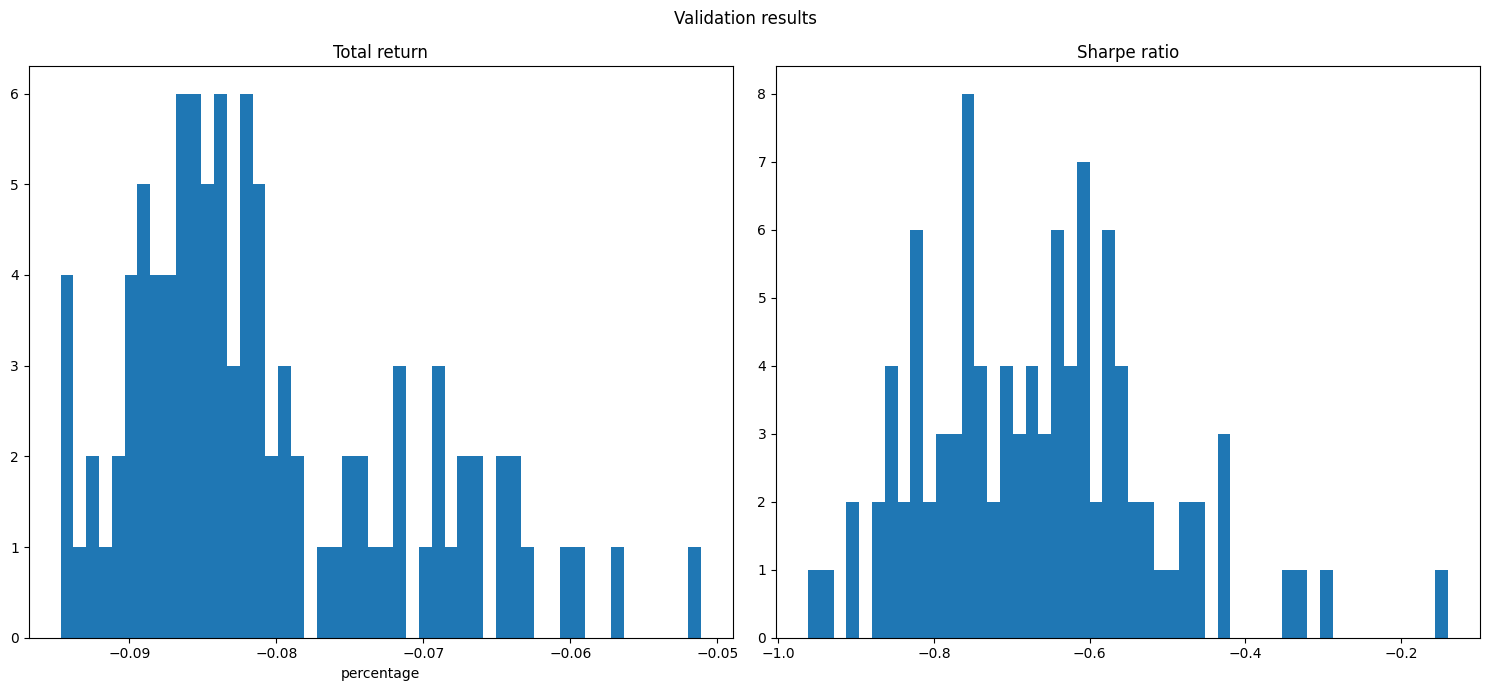

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

axs[0].hist([np.exp(sum(x)) - 1 for x in total_rewards], bins=50)
axs[0].set_xlabel("percentage")
axs[0].set_title("Total return")

axs[1].hist([np.mean(x) / np.std(x) for x in total_rewards], bins=50)
axs[1].set_xlabel("")
axs[1].set_title("Sharpe ratio")

fig.suptitle("Validation results")
plt.tight_layout()
plt.show()

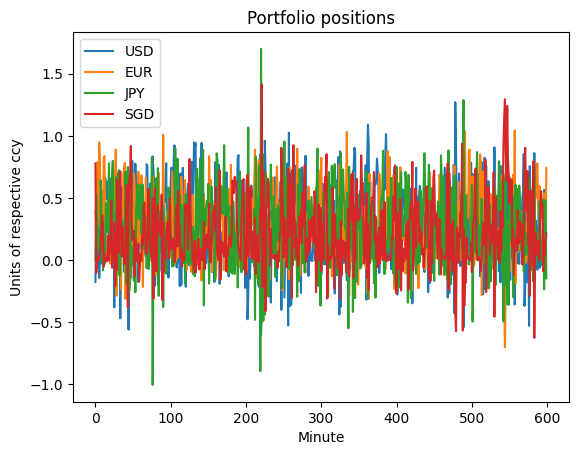

In [26]:
pd.DataFrame.from_dict(portfolio_pos[5]).plot()
plt.title("Portfolio positions")
plt.xlabel("Minute")
plt.ylabel("Units of respective ccy")
plt.show()

In [27]:
fx_env.close()

---
## RLLib setup

In [28]:
def env_creator(env_config):
    """
    Create env
    """
    fx_env = FxTradingEnv(**env_config)
    fx_env.preprocess_data()
    return fx_env

In [29]:
register_env("fx_trading_env", env_creator)
ModelCatalog.register_custom_model("fx_model", FXModel)

In [30]:
ray.init(
    ignore_reinit_error=True,
    # # To work with cloned repository
    # # Comment for Google collab or if you use pip install
    runtime_env={
        "working_dir": os.path.dirname(os.path.abspath(".")),
        "py_modules": [os.path.abspath(".")],
        "excludes": [
            "*.pyc",
            "__pycache__",
            "*.parquet.gzip",
            "*data/",
            "notebooks/",
            ".git/",
        ],
    },
)

2026-02-24 20:52:53,465	INFO worker.py:2023 -- Started a local Ray instance.
2026-02-24 20:52:53,515	INFO packaging.py:588 -- Creating a file package for local module 'C:\Users\Ivan\rl_trading\notebooks'.
2026-02-24 20:52:53,546	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_67dfe9c648c9667d.zip' (1.09MiB) to Ray cluster...
2026-02-24 20:52:53,550	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_67dfe9c648c9667d.zip'.
2026-02-24 20:52:53,659	INFO packaging.py:588 -- Creating a file package for local module 'C:\Users\Ivan\rl_trading'.
2026-02-24 20:52:53,770	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_7096f0c940c5427d.zip' (0.68MiB) to Ray cluster...
2026-02-24 20:52:53,776	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_7096f0c940c5427d.zip'.
C:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no lon

Python version:,3.12.10
Ray version:,2.52.1


(pid=gcs_server) [2026-02-24 20:53:24,020 E 8580 1516] (gcs_server.exe) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-02-24 20:53:27,417 E 16424 2640] (raylet.exe) main.cc:979: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(RolloutWorker pid=16228) 2026-02-24 21:32:31,731	ERROR actor_manager.py:186 -- Worker exception caught during `apply()`: Observation ([ 1.69448496e+04  1.29675344e+05  3.99852612e+03 -1.50617719e+05
(RolloutWorker pid=16228)   1.10159025e+01 -6.49596357e+00 -1.68302841e+01 -1.49385512e+00
(RolloutWorker pid=16228)  -5.93727708e-01 -6.15151596e+00 -2.93178201e-01 -8.65183651e-01
(RolloutWorker pid=16228)   3.99355483e+00  4.27

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: 00000000d749e58f8c533faad1f58b48be135e6d124fbb2389a6e0f7be56a016 Worker ID: 87423254c7a9567e2d707bafad0c14ba52ac3c2669d1a9ca4fcc66d3 Node ID: e3d9920836767c2e6aa10c65a7615ded99e0eff820d85ff4394696f3 Worker IP address: 127.0.0.1 Worker port: 57249 Worker PID: 16228 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker exits unexpectedly. Worker exits with an exit code 1.


(RolloutWorker pid=2468) 2026-02-24 21:44:11,780	ERROR actor_manager.py:186 -- Worker exception caught during `apply()`: Observation ([-2.2555522e+05  2.3065053e+05 -6.9410711e+04  6.4316402e+04
(RolloutWorker pid=2468)  -2.9674432e+00  1.0164952e+00 -3.3274410e+00 -5.1563847e-01
(RolloutWorker pid=2468)   1.1151539e+00  7.6504767e-01 -6.9501919e-01  3.5590085e-01
(RolloutWorker pid=2468)  -1.2780964e-01 -1.4559518e-01 -3.1978521e-01 -2.2815064e-01
(RolloutWorker pid=2468)  -6.3352257e-01 -1.8547848e-01 -1.5133420e+00  8.8752037e-01
(RolloutWorker pid=2468)  -3.7784916e-01 -1.4157462e-02  1.1408428e+00  6.0433376e-01
(RolloutWorker pid=2468)  -3.9571635e-03 -3.4031692e-01 -1.2590915e-01  1.5532167e-01
(RolloutWorker pid=2468)   7.3308158e-01  5.2436185e-01 -5.0000000e-01 -8.6602539e-01
(RolloutWorker pid=2468) ValueError: Observation ([-2.2555522e+05  2.3065053e+05 -6.9410711e+04  6.4316402e+04
(RolloutWorker pid=2468)  -2.9674432e+00  1.0164952e+00 -3.3274410e+00 -5.1563847e-01
(Rollo

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: 040000006fc80ba8d604e72a5ec3346e066b1318678a1b3508bc1ee42d791e00 Worker ID: e05dbbae27023c455b84728b30afc2e7160f1599e5a5f7a47d3ba549 Node ID: e3d9920836767c2e6aa10c65a7615ded99e0eff820d85ff4394696f3 Worker IP address: 127.0.0.1 Worker port: 57281 Worker PID: 2468 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker exits unexpectedly. Worker exits with an exit code 1.


(RolloutWorker pid=16540) 2026-02-24 21:46:47,431	ERROR actor_manager.py:186 -- Worker exception caught during `apply()`: Observation ([ 1.4291352e+05  4.8807715e+04  1.0313745e+05 -2.9485769e+05
(RolloutWorker pid=16540)   2.1089296e+01 -3.4340882e+00  1.1184069e+01  3.0835569e-01
(RolloutWorker pid=16540)  -1.1644354e+00 -9.6145892e-01  3.0144402e-01 -9.5198929e-01
(RolloutWorker pid=16540)  -1.2547750e+00 -2.9807312e+00 -1.9658284e+00  1.9458195e+00
(RolloutWorker pid=16540)  -8.9327365e-02  8.0569988e-01 -1.3691342e+00  1.6959851e+00
(RolloutWorker pid=16540)   1.4716977e+00  1.9249067e-01  1.2016679e+00 -1.3154027e+00
(RolloutWorker pid=16540)  -6.9499147e-01 -4.9377661e-02  5.9337372e-01  3.4703264e-01
(RolloutWorker pid=16540)   1.1169127e+00 -3.8228668e-02  5.0000000e-01 -8.6602539e-01
(RolloutWorker pid=16540) Traceback (most recent call last):
(RolloutWorker pid=16540)   File "C:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\rllib\utils\actor_manage

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. Lease ID: 08000000b31864155b6a463b3408de3f62f28df2b5b7a0aef3fa708b8bec2121 Worker ID: 91035422c1b0d01afb7d4f697f9854290439f4e5d525bfcfdae0a323 Node ID: e3d9920836767c2e6aa10c65a7615ded99e0eff820d85ff4394696f3 Worker IP address: 127.0.0.1 Worker port: 52033 Worker PID: 16540 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker exits unexpectedly. Worker exits with an exit code 1.


In [31]:
# Use all available CPUs minus 1
# Use all GPUs if available
suggested_workers = max(os.cpu_count() - 1, 1)

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
else:
    num_gpus = 0

suggested_workers, num_gpus

(7, 0)

In [32]:
historical_prices_ref = ray.put(train_prices)
features_ref = ray.put(train_data)

In [33]:
ENV_CONFIG.update(
    {"historical_prices": historical_prices_ref, "features_dataset": features_ref}
)

In [34]:
pprint(ENV_CONFIG)

{'episode_length_days': 10,
 'features_dataset': ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000002e1f505),
 'historical_prices': ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505),
 'initial_portfolio': {'USD': 100000},
 'start_datetime': None,
 'ticker_set': ('EURJPY', 'EURUSD', 'SGDJPY', 'USDJPY', 'USDSGD'),
 'trading_params': {'action_penalty': 0.05,
                    'base_currency': 'USD',
                    'long_only': True,
                    'max_delta_in_weights': 0.99,
                    'no_trade_penalty': 0.5,
                    'reward': 'total_profit',
                    'sharpe_eta': 0.1,
                    'slippage': (0.0001, 0.0002),
                    'trade_fee': 0.0001}}


In most PPO implementations (including RLlib), 3–10 epochs per batch is typical. Using more can actually increase the risk of getting stuck in local minima because the policy may overfit to the current batch of data, causing it to lose generalization and converge prematurely.

In [35]:
config = PPOConfig()

config = (
    config.environment(
        env="fx_trading_env",
        env_config=ENV_CONFIG,
    )
    .framework("torch")
    .training(
        model={"custom_model": "fx_model"},
        lr=3e-4,
        clip_param=0.2,
        grad_clip=0.5,
        vf_clip_param=10.0,
        entropy_coeff=0.01,
        gamma=0.99,
        lambda_=0.95,
        num_epochs=8,
        train_batch_size=int(16384 * ENV_CONFIG["episode_length_days"]),
    )
    .debugging(log_level="ERROR")  # DEBUG
    .resources(num_gpus=num_gpus)
    .env_runners(
        num_cpus_per_env_runner=1,
        num_env_runners=suggested_workers,
        num_envs_per_env_runner=4,
        rollout_fragment_length="auto",
        exploration_config={
            "type": "StochasticSampling",  # default
            "random_timesteps": 5_000,
        },
    )
    # .evaluation(
    #     evaluation_interval=5,
    #     evaluation_config={
    #         "explore": False,
    #     }
    # )
    .api_stack(
        enable_rl_module_and_learner=False, enable_env_runner_and_connector_v2=False
    )
)

In [36]:
trainer = config.build_algo()

C:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\rllib\algorithms\algorithm.py:525: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
C:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\tune\logger\unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
C:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\ray\tune\logger\unified.py:53: RayDeprec

25 features + 5 prices + 5 time features 

In [38]:
trainer.get_policy().observation_space

Box(-100000.0, 100000.0, (35,), float32)

5 ccys

In [39]:
trainer.get_policy().action_space

Box(-1.0, 1.0, (5,), float32)

---
## Train the model

In [40]:
num_epochs = 200
# will not be applied for first 100
early_stopping_patience = 20
min_improvement = 0.01
best_reward = -np.inf

In [41]:
# warnings.filterwarnings('ignore')
episode_rewards = []
patience_counter = 0

for i in trange(num_epochs):

    result = trainer.train()

    average_episode_reward = np.mean(
        result[ENV_RUNNER_RESULTS]["hist_stats"]["episode_reward"]
    )
    episode_rewards.append(average_episode_reward)

    if np.mean(episode_rewards[-5:]) >= best_reward + min_improvement:
        best_reward = np.mean(episode_rewards[-5:])
        patience_counter = 0
    else:
        patience_counter += 1

    if (patience_counter > early_stopping_patience) and (i > 100):
        print(f"Early stopping! No improvements for {patience_counter} steps")
        break
    
    if i % 5 == 0:
        print(f"Last 5 epochs reward: {np.mean(episode_rewards[-5:])}")

  0%|▍                                                                             | 1/200 [03:09<10:27:30, 189.20s/it]

Last 5 epochs reward: -74.84532911420536


  3%|██▍                                                                             | 6/200 [13:09<5:19:48, 98.91s/it]

Last 5 epochs reward: -89.57681747651691


  6%|████▎                                                                          | 11/200 [19:01<3:54:45, 74.52s/it]

...

Last 5 epochs reward: -14.121065636588787


 14%|███████████▍                                                                   | 29/200 [51:04<4:18:57, 90.86s/it]2026-02-24 21:46:09,617	ERROR actor_manager.py:973 -- Ray error (The actor 6215e3efa6358282d0ba191001000000 is unavailable: The actor is temporarily unavailable: IOError: The actor was restarted. The task may or may not have been executed on the actor.), taking actor 5 out of service.
2026-02-24 21:46:09,617	ERROR actor_manager.py:771 -- The actor 6215e3efa6358282d0ba191001000000 is unavailable: The actor is temporarily unavailable: IOError: The actor was restarted. The task may or may not have been executed on the actor.
NoneType: None
 15%|███████████▊                                                                   | 30/200 [52:14<3:59:48, 84.64s/it]2026-02-24 21:47:48,635	ERROR actor_manager.py:973 -- Ray error (The actor 6215e3efa6358282d0ba191001000000 is unavailable: The actor is temporarily unavailable: IOError: The actor was restarted. The task may or may not

Last 5 epochs reward: -11.738999471389212


 17%|█████████████▎                                                                | 34/200 [58:04<4:43:32, 102.48s/it]


KeyboardInterrupt: 

In [43]:
episode_rewards

[np.float64(nan)]

### Save pytorch model for later evaluation

We save only pytorch part to ensure latency and easier changes

In [42]:
policy = trainer.get_policy()

In [28]:
MODEL_NAME = "ALL_CCY_MODEL_WEIGHTS_1_MIN_1_DAY.pth"

In [44]:
torch.save(policy.model.state_dict(), f"../trained_models/{MODEL_NAME}")

### Plot training results

Includes action penalty

In [45]:
rewards = pd.Series(episode_rewards)

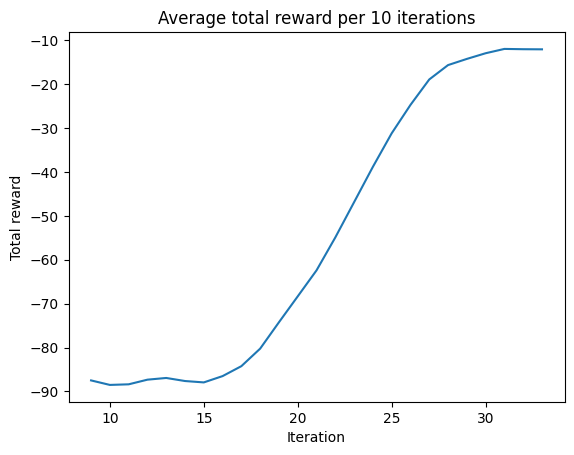

In [46]:
rewards.rolling(10).mean().plot()
plt.title("Average total reward per 10 iterations")
plt.xlabel("Iteration")
plt.ylabel("Total reward")
plt.show()

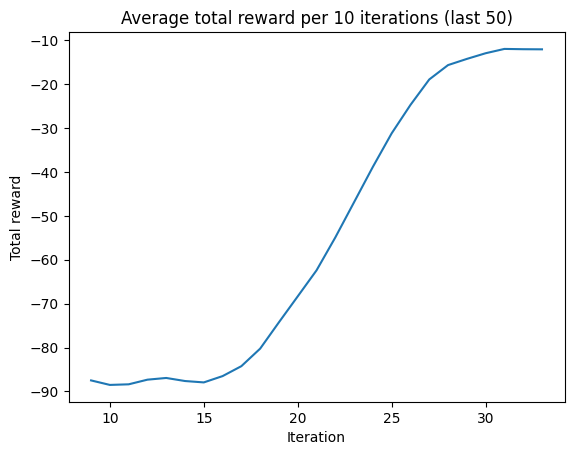

In [47]:
rewards.rolling(10).mean().iloc[-50:].plot()
plt.title("Average total reward per 10 iterations (last 50)")
plt.xlabel("Iteration")
plt.ylabel("Total reward")
plt.show()

---
## Validate the model

In [88]:
MODEL_NAME = "ALL_CCY_MODEL_WEIGHTS_1_MIN_1_DAY.pth"

In [89]:
ENV_VALIDATION_CONFIG["episode_length_days"] = 1e3

In [90]:
ENV_VALIDATION_CONFIG["initial_portfolio"] = {'USD': 100000, "EUR": 100000, "SGD": 100000, "JPY": 10000}

In [91]:
ENV_VALIDATION_CONFIG["start_datetime"] = pd.Timestamp('2023-12-04 09:00:00')

In [92]:
fx_env = FxTradingEnv(**ENV_VALIDATION_CONFIG)

In [93]:
fx_env.preprocess_data()

In [94]:
state_dict = torch.load(f"../trained_models/{MODEL_NAME}")

In [95]:
num_ccy = fx_env.action_space.shape[0]

In [96]:
trained_model = FXModel(
    obs_space=fx_env.observation_space,
    action_space=fx_env.action_space,
    num_outputs=num_ccy * 2,
    model_config={},
    name="FXModel",  # any name if fine
)

In [97]:
trained_model.load_state_dict(state_dict)
trained_model.eval()

FXModel(
  (main_net): Sequential(
    (0): Linear(in_features=35, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
  )
  (mean_net): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
    (1): Tanh()
  )
  (log_std_net): Sequential(
    (0): Linear(in_features=64, out_features=5, bias=True)
  )
  (value_net): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=1, bi

In [98]:
execution_times = []
portfolio_pos = []
total_rewards = []
all_actions = []

for _ in trange(100):

    state, info = fx_env.reset()

    start_time = pd.Timestamp.now()
    done = False

    current_portfolio = []
    total_reward = []
    this_time_actions = []

    while not done:

        torch_state = torch.from_numpy(state).type(torch.float32)

        with torch.no_grad():
            action, _ = trained_model(
                input_dict={"obs": torch_state}, state=[], seq_lens=None
            )

        action = action.detach().numpy()[:num_ccy]
        this_time_actions.append(action)

        state, reward, terminated, truncated, info = fx_env.step(action)
        done = terminated or truncated

        if not done:
            current_portfolio.append(deepcopy(info["portfolio"]))
            total_reward.append(reward)

    execution_times.append((pd.Timestamp.now() - start_time).total_seconds())
    total_rewards.append(deepcopy(total_reward))
    portfolio_pos.append(deepcopy(current_portfolio))
    all_actions.append(deepcopy(this_time_actions))

  0%|                                                                                          | 0/100 [00:29<?, ?it/s]


KeyboardInterrupt: 

In [99]:
portfolio_pos = []
total_rewards = []
all_actions = []

state, info = fx_env.reset()

start_time = pd.Timestamp.now()
done = False

for _ in tqdm(fx_env.historical_prices):

    torch_state = torch.from_numpy(state).type(torch.float32)

    with torch.no_grad():
        action, _ = trained_model(
            input_dict={"obs": torch_state}, state=[], seq_lens=None
        )

    action = action.detach().numpy()[:num_ccy]
    all_actions.append(action)

    state, reward, terminated, truncated, info = fx_env.step(action)
    done = terminated or truncated

    if done:
        break

    portfolio_pos.append(deepcopy(info["portfolio"]))
    total_rewards.append(reward)

100%|████████████████████████████████████████████████████████████████████████▊| 160611/161093 [06:25<00:01, 416.15it/s]


In [109]:
for date, prices in tqdm(validate_prices.items()):
    break

In [111]:
ENV_VALIDATION_CONFIG["initial_portfolio"]

{'USD': 100000, 'EUR': 100000, 'SGD': 100000, 'JPY': 10000}

In [100]:
# np.isnan(np.array(total_reward)).any()

In [101]:
total_rewards = [np.array(x) for x in total_rewards]

TypeError: iteration over a 0-d array

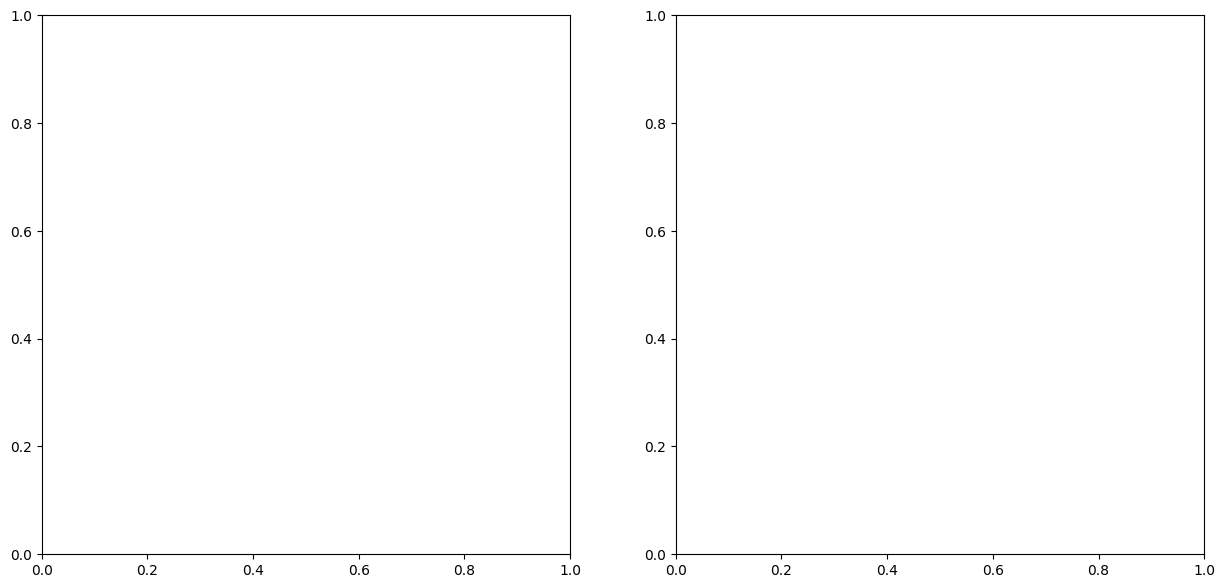

In [102]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

axs[0].hist([np.exp(sum(x)) - 1 for x in total_rewards], bins=50)
axs[0].set_xlabel("percentage")
axs[0].set_title("Total return")

axs[1].hist([np.mean(x) / np.std(x) for x in total_rewards], bins=50)
axs[1].set_xlabel("")
axs[1].set_title("Sharpe ratio")

fig.suptitle("Validation results")
plt.tight_layout()
plt.show()

In [103]:
x = np.insert(np.array(total_rewards), 0, 0)

In [104]:
dates = list(fx_env.historical_prices.keys())[:len(x)]

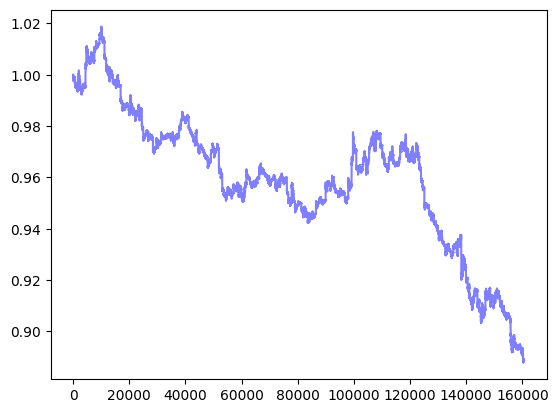

In [105]:
plt.plot(np.cumprod(1 + x), alpha=0.5, color="blue")

More stable positions in trading, some positive returns

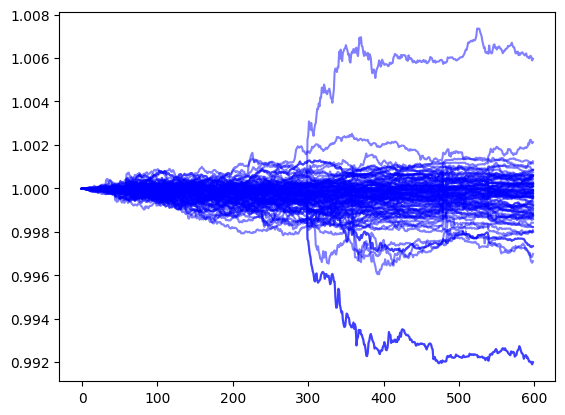

In [40]:
for x in total_rewards:
    plt.plot(np.cumprod(1 + x), alpha=0.5, color="blue")
plt.show()

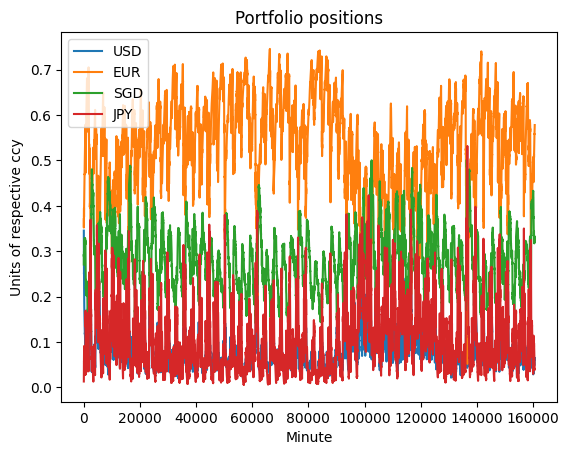

In [106]:
pd.DataFrame.from_dict(portfolio_pos).plot()
plt.title("Portfolio positions")
plt.xlabel("Minute")
plt.ylabel("Units of respective ccy")
plt.show()

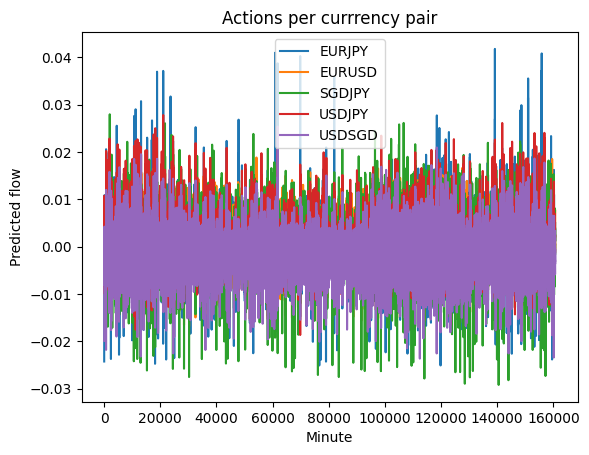

In [107]:
pd.DataFrame(all_actions, columns=TICKER_SET).plot()
plt.title("Actions per currrency pair")
plt.xlabel("Minute")
plt.ylabel("Predicted flow")
plt.show()